In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%pip install xgboost

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import joblib 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [4]:
df = pd.read_csv('german_credit_data.csv')

In [5]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
df = df.drop(columns=['Unnamed: 0'], axis=1)

In [7]:
df = df.dropna().reset_index(drop=True)

In [8]:
print(df['Risk'].value_counts(normalize=True) * 100)

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64


In [9]:
df.shape

(522, 10)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               522 non-null    int64 
 1   Sex               522 non-null    object
 2   Job               522 non-null    int64 
 3   Housing           522 non-null    object
 4   Saving accounts   522 non-null    object
 5   Checking account  522 non-null    object
 6   Credit amount     522 non-null    int64 
 7   Duration          522 non-null    int64 
 8   Purpose           522 non-null    object
 9   Risk              522 non-null    object
dtypes: int64(4), object(6)
memory usage: 40.9+ KB


In [11]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,522.0,NaN,NaN,NaN,34.888889,11.787918,19.0,26.0,31.5,41.0,75.0
Sex,522,2,male,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,522.0,NaN,NaN,NaN,1.875479,0.682811,0.0,2.0,2.0,2.0,3.0
Housing,522,3,own,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,522,4,little,412,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,522,3,little,245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,522.0,NaN,NaN,NaN,3278.745211,2929.155177,276.0,1297.5,2326.5,3971.25,18424.0
Duration,522.0,NaN,NaN,NaN,21.33908,12.474079,6.0,12.0,18.0,26.75,72.0
Purpose,522,8,car,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Risk,522,2,good,291,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df["Job"].unique()

array([2, 3, 1, 0])

In [13]:
df.isna().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

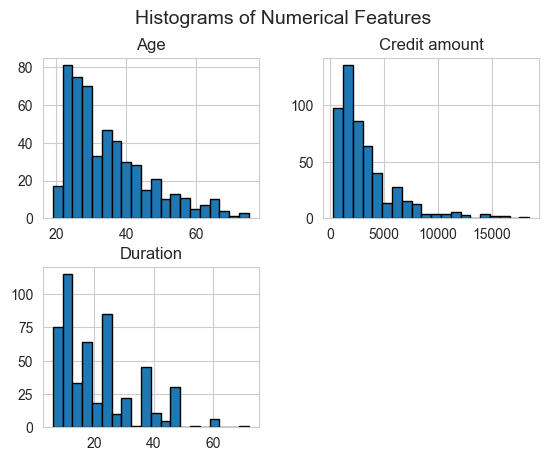

In [14]:
df[['Age', 'Credit amount', 'Duration']].hist(bins=20,edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=14)
plt.show()

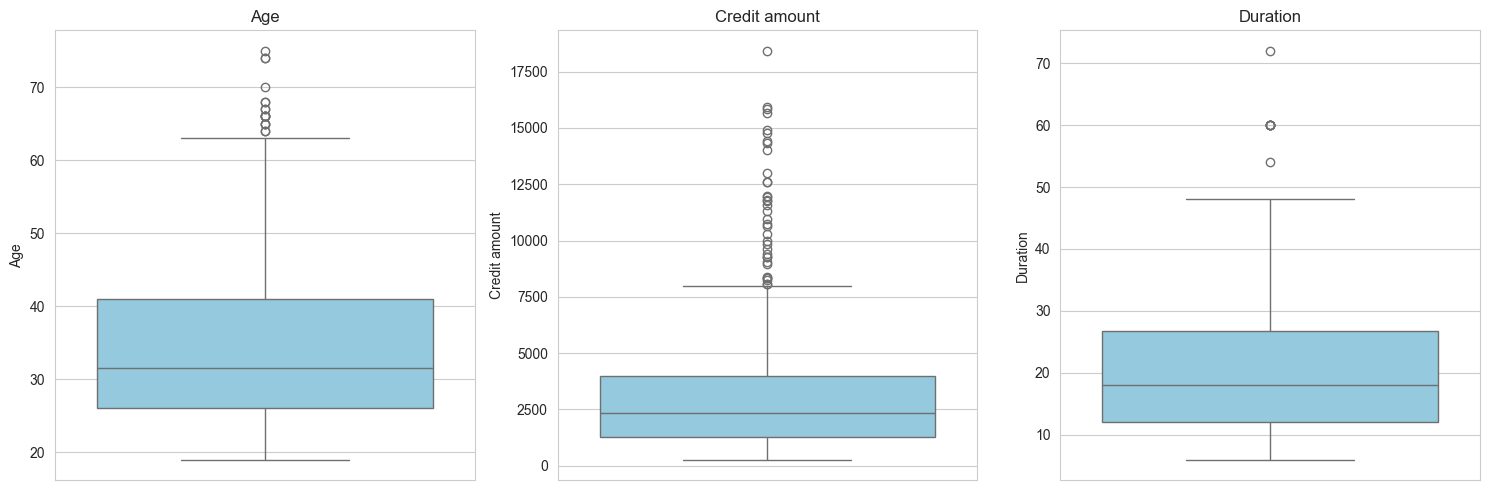

In [15]:
plt.figure(figsize=(15,5))
for i,col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col],color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

In [16]:
df.query("Duration >=60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [17]:
categorical_cols=['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

C:\Users\User\AppData\Local\Temp\ipykernel_30472\2981489417.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col,palette='Set2',order=df[col].value_counts().index)
C:\Users\User\AppData\Local\Temp\ipykernel_30472\2981489417.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col,palette='Set2',order=df[col].value_counts().index)
C:\Users\User\AppData\Local\Temp\ipykernel_30472\2981489417.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col,palette='Set2',order=df[col].value_counts().index)
C:\User

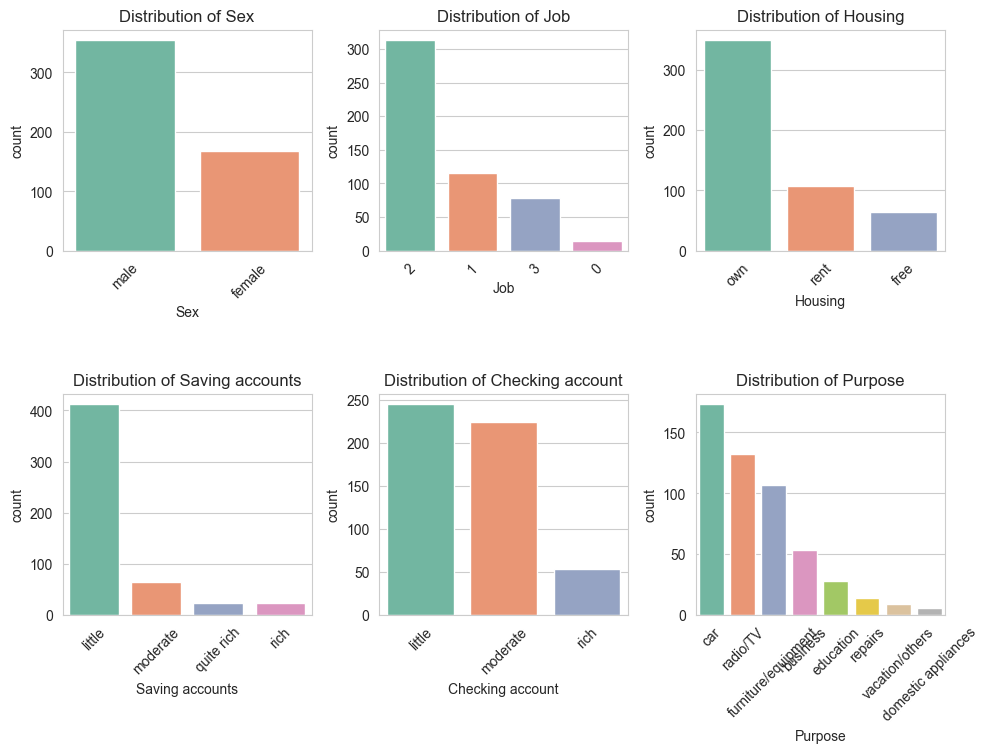

In [18]:
plt.figure(figsize=(10,10))
for i,col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, x=col,palette='Set2',order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
corr=df[['Age', 'Job', 'Credit amount', 'Duration']].corr()

In [20]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


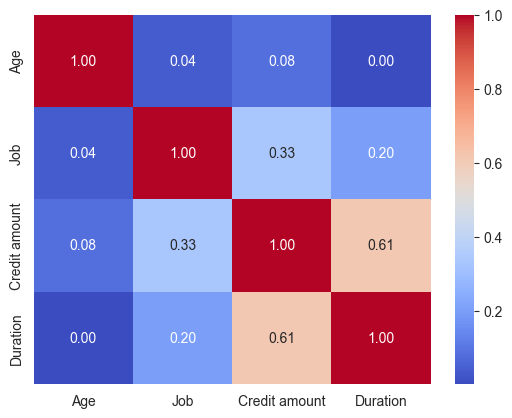

In [21]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [22]:
df.groupby('Job')['Credit amount'].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [23]:
df.groupby('Sex')['Credit amount'].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [24]:
pd.pivot_table(df, values='Credit amount', index='Housing', columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


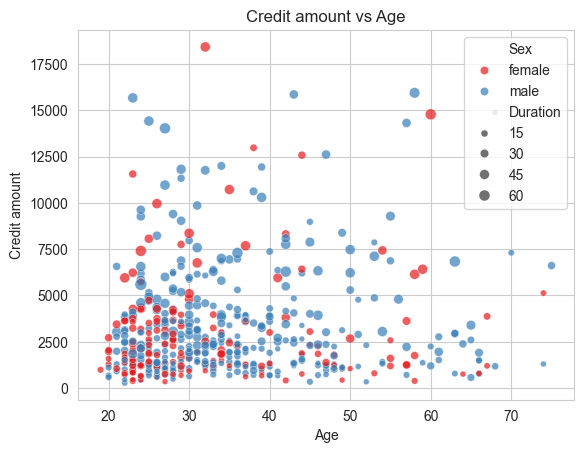

In [25]:
sns.scatterplot(data=df, x='Age', y='Credit amount', hue='Sex', size='Duration', alpha=0.7,palette='Set1')
plt.title('Credit amount vs Age')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_30472\3481845904.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Saving accounts', y='Credit amount', palette='pastel')


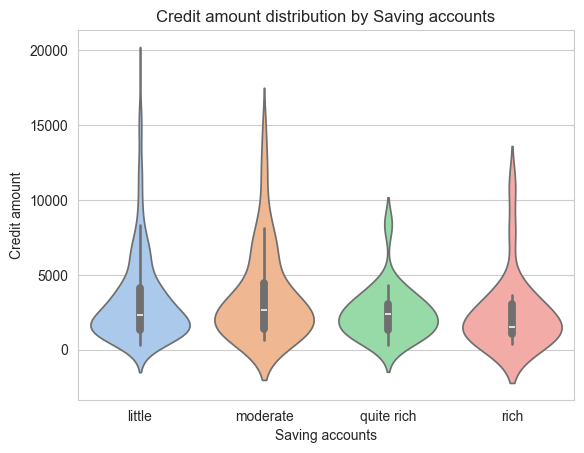

In [26]:
sns.violinplot(data=df, x='Saving accounts', y='Credit amount', palette='pastel')
plt.title('Credit amount distribution by Saving accounts')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_30472\1979015521.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='pastel')
C:\Users\User\AppData\Local\Temp\ipykernel_30472\1979015521.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='pastel')
C:\Users\User\AppData\Local\Temp\ipykernel_30472\1979015521.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='pastel')


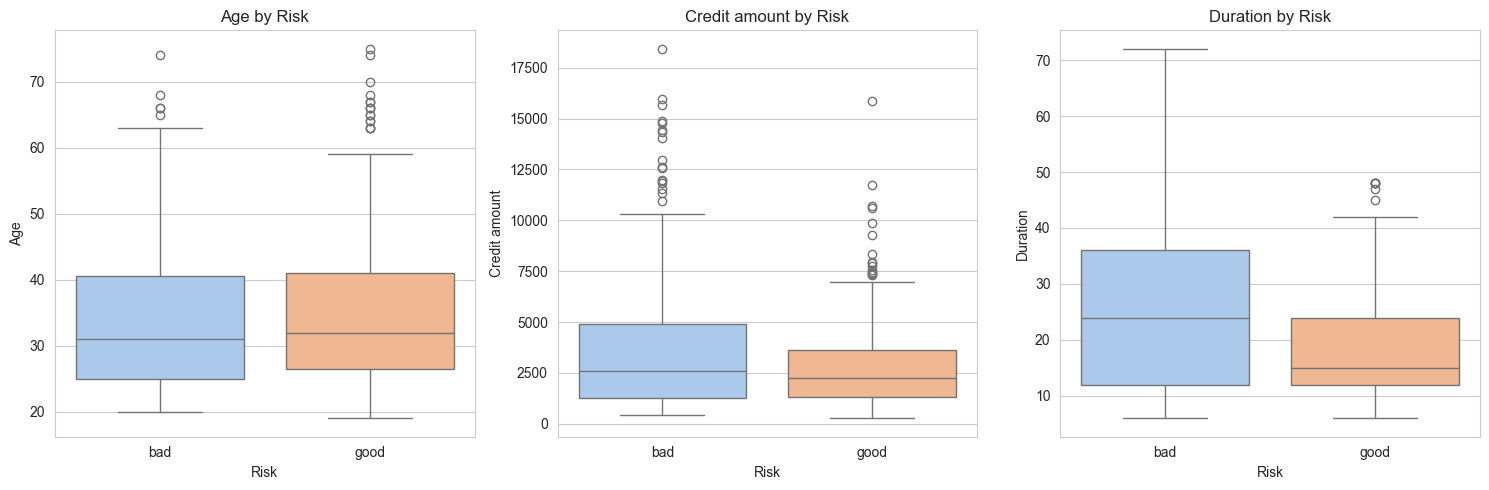

In [27]:
plt.figure(figsize=(15,5))
for i,col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df, x='Risk', y=col, palette='pastel')
    plt.title(f'{col} by Risk')
plt.tight_layout()
plt.show()

In [28]:
df.groupby('Risk')[['Age', 'Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [29]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

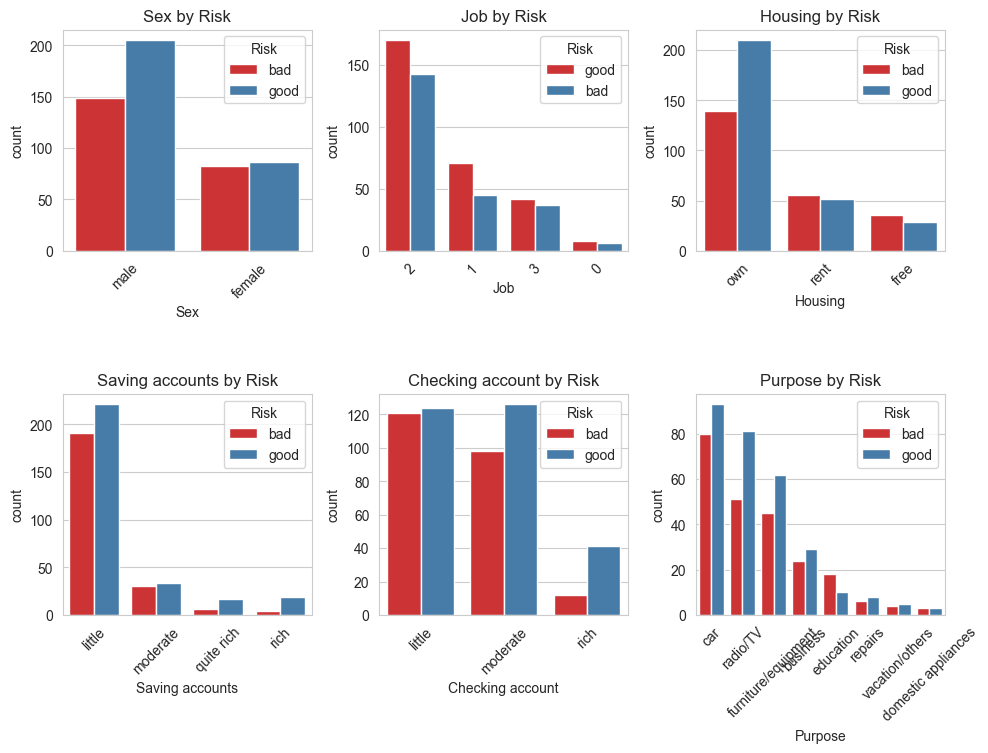

In [30]:
plt.figure(figsize=(10,10))
for i,col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, x=col, hue='Risk', palette='Set1', order=df[col].value_counts().index)
    plt.title(f'{col} by Risk')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [32]:
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration']
target= 'Risk'

In [33]:
df_model = df[features+ [target]].copy()

In [34]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [35]:
cat_cols = df_model.select_dtypes(include='object').columns.drop('Risk')

In [36]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [37]:
le_dict={}

In [38]:
for col in cat_cols:
    le=LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    le_dict[col]=le
    joblib.dump(le, f'{col}_encoder.pkl')  

In [39]:
target

'Risk'

In [40]:
le_target = LabelEncoder()
df_model[target] = le_target.fit_transform(df_model[target])

In [41]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [42]:
joblib.dump(le_target,"target_encoder.pkl")

['target_encoder.pkl']

In [43]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [44]:
X = df_model.drop(target,axis=1)
y = df_model[target]

In [45]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [46]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,stratify=y,random_state=42)

In [48]:
X_train.shape

(417, 8)

In [49]:
X_test.shape

(105, 8)

In [50]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1 # Use all available cores for speed
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    return best_model, accuracy, grid.best_params_

In [51]:
dt = DecisionTreeClassifier(random_state=1, class_weight='balanced')
dt_param_grid = {
    'max_depth': [3,5,7,10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [52]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [53]:
print(f"Decision Tree Accuracy:",acc_dt)

Decision Tree Accuracy: 0.6


In [54]:
print(f"Best Parameters:", params_dt)

Best Parameters: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [55]:
rf = RandomForestClassifier(random_state=1, class_weight='balanced',n_jobs=-1)
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [56]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [57]:
print(f"Random Forest Accuracy:",acc_rf)

Random Forest Accuracy: 0.6476190476190476


In [58]:
print(f"Best Parameters:", params_rf)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [59]:
et= ExtraTreesClassifier(random_state=1, class_weight='balanced', n_jobs=-1)
et_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

print(f"Extra Trees Accuracy:",acc_et)
print(f"Best Parameters:",params_et)


Extra Trees Accuracy: 0.6095238095238096
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}


In [60]:
xgb=XGBClassifier(random_state=1, scale_pos_weight= (y_train==0).sum() / (y_train==1).sum(), use_label_encoder=False, eval_metric='logloss')

In [61]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7,1],
    'colsample_bytree': [0.7,1]
}

In [62]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [18:26:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [63]:
print(f"XGBoost Accuracy:",acc_xgb)
print(f"Best Parameters:", params_xgb)

XGBoost Accuracy: 0.6761904761904762
Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}


In [64]:
best_et.predict(X_test)


array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0])

In [65]:
print(f"XGBoost Accuracy:",acc_xgb)
print(f"Extra Trees Accuracy:",acc_et)
print(f"Random Forest Accuracy:",acc_rf)
print(f"Decision Tree Accuracy:",acc_dt)

XGBoost Accuracy: 0.6761904761904762
Extra Trees Accuracy: 0.6095238095238096
Random Forest Accuracy: 0.6476190476190476
Decision Tree Accuracy: 0.6


In [66]:
joblib.dump(best_xgb, 'xgb_credit_model.pkl')

['xgb_credit_model.pkl']